Main code

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
#os.chdir("/content/drive/MyDrive/Colab Notebooks/CNN_HW/HW1")
os.chdir("/content/drive/MyDrive/Colab Notebooks/CNN_HW/HW1")

In [ ]:
import tensorflow as tf
from tensorflow import keras
import cv2
import glob
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from keras import regularizers

In [ ]:
dataFolder = '/content/drive/MyDrive/Colab Notebooks/CNN_HW/HW1/chest_xray'
#dataFolder = '/content/drive/MyDrive/Colab Notebooks/CNN_HW/HW1/dummy'

dataDict = {}
for folder in os.listdir(dataFolder):
  insideFolder = dataFolder + '/' + folder
  dataDict[f'{folder}_y'] = []
  dataDict[f'{folder}_im'] = []
  print("start going through folder: " + folder)
  for subfolder in os.listdir(insideFolder):
    subfolder = insideFolder + '/' + subfolder + '/'

    #y = []
    images = []
    dir = subfolder
    ext = ['jpeg']

    path=os.path.dirname(dir)
    if os.path.basename(path) == 'NORMAL':
      y = [0 for i in range(0,len(os.listdir(dir)))]
    else:
      y = [1 for i in range(0,len(os.listdir(dir)))]

    files = []
    [files.extend(glob.glob(dir + '*.' + e)) for e in ext]
    for file in files:
      im = cv2.imread(file)
      recized_im = cv2.resize(im,(224, 224)) 
      images.append(recized_im)
    dataDict[f'{folder}_y'] += y #needs to be fixed
    dataDict[f'{folder}_im'] += images
    
    print("done with subfolder: " + os.path.basename(path))
  print("done with folder: " + folder)  

start going through folder: train
done with subfolder: NORMAL
done with subfolder: PNEUMONIA
done with folder: train
start going through folder: test
done with subfolder: NORMAL
done with subfolder: PNEUMONIA
done with folder: test
start going through folder: val
done with subfolder: NORMAL
done with subfolder: PNEUMONIA
done with folder: val


In [ ]:
# get data with augmantation

data_augmentation = tf.keras.Sequential([
  keras.layers.RandomFlip("horizontal_and_vertical"),
  keras.layers.RandomRotation(0.2),
])

dataFolder = '/content/drive/MyDrive/Colab Notebooks/CNN_HW/HW1/chest_xray'
#dataFolder = '/content/drive/MyDrive/Colab Notebooks/CNN_HW/HW1/dummy'

dataDict = {}
for folder in os.listdir(dataFolder):
  insideFolder = dataFolder + '/' + folder
  dataDict[f'{folder}_y'] = []
  dataDict[f'{folder}_im'] = []
  print("start going through folder: " + folder)
  for subfolder in os.listdir(insideFolder):
    subfolder = insideFolder + '/' + subfolder + '/'

    #y = []
    images = []
    dir = subfolder
    ext = ['jpeg']

    path=os.path.dirname(dir)
    if os.path.basename(path) == 'NORMAL':
      y = [0 for i in range(0,len(os.listdir(dir)))]
    else:
      y = [1 for i in range(0,len(os.listdir(dir)))]

    files = []
    [files.extend(glob.glob(dir + '*.' + e)) for e in ext]
    for file in files:
      im = cv2.imread(file)
      recized_im = cv2.resize(im,(224, 224)) 
      images.append(recized_im)
    dataDict[f'{folder}_y'] += y
    dataDict[f'{folder}_im'] += images

    if folder == 'train':
      if os.path.basename(path) == 'NORMAL':
        aug_im_h = data_augmentation(np.array(images))
        aug_im_h2 = np.array(aug_im_h)
        aug_im = aug_im_h2.tolist()

        dataDict[f'{folder}_im'] += aug_im
        dataDict[f'{folder}_y'] += y

    print("done with subfolder: " + os.path.basename(path))
  print("done with folder: " + folder)  

start going through folder: test
done with subfolder: NORMAL
done with subfolder: PNEUMONIA
done with folder: test
start going through folder: train
done with subfolder: NORMAL
done with subfolder: PNEUMONIA
done with folder: train
start going through folder: val
done with subfolder: PNEUMONIA
done with subfolder: NORMAL
done with folder: val


In [ ]:
print(np.shape(dataDict['train_im']))
print(np.shape(dataDict['train_y']))
print(np.shape(dataDict['val_im']))
print(np.shape(dataDict['val_y']))
print(np.shape(dataDict['test_im']))
print(np.shape(dataDict['test_y']))

(6557, 224, 224, 3)
(6557,)
(16, 224, 224, 3)
(16,)
(624, 224, 224, 3)
(624,)


In [ ]:
# models cell

opt = keras.optimizers.Adam(learning_rate=1e-3) #lr=1e-3
#opt = keras.optimizers.Adam()

## DNN model ------------------------------------------------------------------

DNNmodel = keras.Sequential([
  keras.layers.BatchNormalization(),
  keras.layers.Dense(units = 64, activation = 'relu', input_shape = (224*224*3,)),
  keras.layers.Dense(units = 64, activation = 'relu', kernel_regularizer=regularizers.l2(l=0.09)),
  keras.layers.Dense(units = 64, activation = 'relu', kernel_regularizer=regularizers.l2(l=0.09)),
  keras.layers.Dense(units = 64, activation = 'relu', kernel_regularizer=regularizers.l2(l=0.09)),
  keras.layers.Dense(units = 64, activation = 'relu', kernel_regularizer=regularizers.l2(l=0.09)),
  keras.layers.Dense(units = 64, activation = 'relu', kernel_regularizer=regularizers.l2(l=0.09)),
  keras.layers.Dense(units = 2, activation = 'softmax')
])

DNNmodel.compile(optimizer=opt, 
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=[keras.metrics.SparseCategoricalAccuracy()])

##------------------------------------------------------------------------------

## CNN model ------------------------------------------------------------------

l = 0.03

CNNmodel = keras.Sequential([

  keras.layers.BatchNormalization(axis=1),  

  keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
  keras.layers.MaxPooling2D((2, 2)),

  keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(l=l)),
  keras.layers.MaxPooling2D((2, 2)),

  keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(l=l)),
  keras.layers.MaxPooling2D((2, 2)),
  
  keras.layers.Flatten(),
  keras.layers.Dense(100, activation="relu", kernel_regularizer=regularizers.l2(l=l)),
  keras.layers.Dense(units = 2, activation = 'softmax')          
])

CNNmodel.compile(optimizer=opt, 
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=[keras.metrics.SparseCategoricalAccuracy()])

##------------------------------------------------------------------------------

In [ ]:
print('----------------DNN summary------------------------\n')
DNNmodel.summary()

print('\n')

print('----------------CNN summary------------------------\n')
CNNmodel.summary()


----------------DNN summary------------------------



ValueError: ignored

In [ ]:
##reshape for DNN and convert to tensor

X_train_DNN = tf.convert_to_tensor(np.reshape(dataDict['train_im'],(np.shape(dataDict['train_im'])[0],-1)), dtype='float32')
X_train_DNN /= 255.0
y_train_DNN = tf.convert_to_tensor(dataDict['train_y'])

X_val_DNN = tf.convert_to_tensor(np.reshape(dataDict['val_im'],(np.shape(dataDict['val_im'])[0],-1)), dtype='float32')
X_val_DNN /= 255.0

## convert to tensor for CNN

X_train_CNN = tf.convert_to_tensor(dataDict['train_im'], dtype='float32')
X_train_CNN /= 255.0
y_train_CNN = tf.convert_to_tensor(dataDict['train_y'])

X_val_CNN = tf.convert_to_tensor(dataDict['val_im'], dtype='float32')
X_val_CNN /= 255.0

In [ ]:
history = DNNmodel.fit(X_train_DNN,y_train_DNN, epochs=30, batch_size=128, validation_split=0.1, shuffle=True)

print(history.history.keys())

# summarize history for accuracy
plt.plot(history.history['sparse_categorical_accuracy'])
plt.plot(history.history['val_sparse_categorical_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()


Epoch 1/30


/usr/local/lib/python3.7/dist-packages/tensorflow/python/util/dispatch.py:1096: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a sigmoid or softmax activation and thus does not represent logits. Was this intended?"
  return dispatch_target(*args, **kwargs)


40/41 [============================>.] - ETA: 0s - loss: 24.8787 - sparse_categorical_accuracy: 0.9078WARNING:tensorflow:Model was constructed with shape (None, 150528) for input KerasTensor(type_spec=TensorSpec(shape=(None, 150528), dtype=tf.float32, name='batch_normalization_9_input'), name='batch_normalization_9_input', description="created by layer 'batch_normalization_9_input'"), but it was called on an input with incompatible shape (224, 224, 3).


ValueError: ignored

In [ ]:
X_test_DNN = tf.convert_to_tensor(np.reshape(dataDict['test_im'],(np.shape(dataDict['test_im'])[0],-1)), dtype='float32')
X_test_DNN /= 255.0

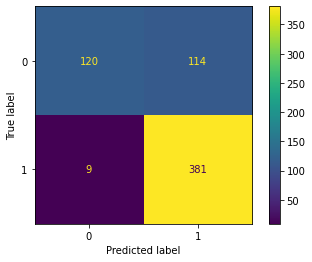

recall is : 0.9769230769230769
precision is: 0.7696969696969697


In [ ]:
y_test_DNN = dataDict['test_y']
y_test_hat_hold = DNNmodel.predict(X_test_DNN)
y_test_hat = np.argmax(y_test_hat_hold, axis=1)
c_mtx = confusion_matrix(y_test_DNN,y_test_hat)

disp = ConfusionMatrixDisplay(confusion_matrix=c_mtx)
disp.plot()
plt.show()


print('recall is : ' + str(recall_score(y_test_DNN,y_test_hat)))
print('precision is: ' + str(precision_score(y_test_DNN,y_test_hat)))


Epoch 1/15


/usr/local/lib/python3.7/dist-packages/tensorflow/python/util/dispatch.py:1096: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a sigmoid or softmax activation and thus does not represent logits. Was this intended?"
  return dispatch_target(*args, **kwargs)


41/41 [==============================] - 72s 2s/step - loss: 8.8247 - sparse_categorical_accuracy: 0.7771 - val_loss: 3.4214 - val_sparse_categorical_accuracy: 0.5640
Epoch 2/15
41/41 [==============================] - 70s 2s/step - loss: 2.0721 - sparse_categorical_accuracy: 0.9420 - val_loss: 1.5226 - val_sparse_categorical_accuracy: 0.9992
Epoch 3/15
41/41 [==============================] - 70s 2s/step - loss: 1.3904 - sparse_categorical_accuracy: 0.9451 - val_loss: 1.2032 - val_sparse_categorical_accuracy: 0.9939
Epoch 4/15
41/41 [==============================] - 69s 2s/step - loss: 1.1240 - sparse_categorical_accuracy: 0.9304 - val_loss: 1.0563 - val_sparse_categorical_accuracy: 0.9771
Epoch 5/15
41/41 [==============================] - 70s 2s/step - loss: 0.8727 - sparse_categorical_accuracy: 0.9542 - val_loss: 0.7426 - val_sparse_categorical_accuracy: 0.9916
Epoch 6/15
41/41 [==============================] - 70s 2s/step - loss: 0.7129 - sparse_categorical_accuracy: 0.9556 - va

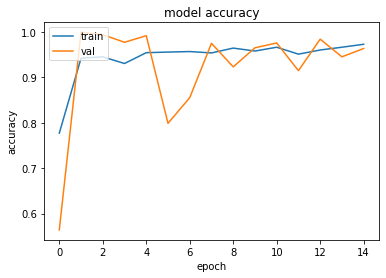

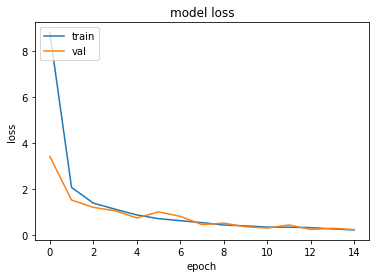

In [ ]:
history = CNNmodel.fit(X_train_CNN,y_train_CNN, epochs=15, batch_size=128, validation_split=0.2, shuffle=True)

print(history.history.keys())

# summarize history for accuracy
plt.plot(history.history['sparse_categorical_accuracy'])
plt.plot(history.history['val_sparse_categorical_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [ ]:
X_test_CNN = tf.convert_to_tensor(dataDict['test_im'], dtype='float32')
X_test_CNN /= 255.0

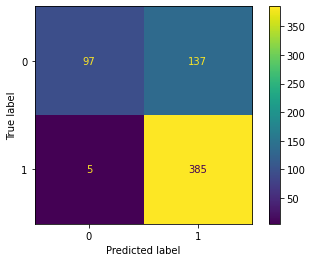

recall is : 0.9871794871794872
precision is: 0.7375478927203065


In [ ]:
y_test_CNN = dataDict['test_y']
y_test_hat_hold = CNNmodel.predict(X_test_CNN)
y_test_hat = np.argmax(y_test_hat_hold, axis=1)
c_mtx = confusion_matrix(y_test_CNN,y_test_hat)

disp = ConfusionMatrixDisplay(confusion_matrix=c_mtx)
disp.plot()
plt.show()


print('recall is : ' + str(recall_score(y_test_CNN,y_test_hat)))
print('precision is: ' + str(precision_score(y_test_CNN,y_test_hat)))
